# Assignment 4: Building a Mini GPT from Scratch

## Imports and Setup

In [1]:
import math
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


---
# Part 1: Data Preparation

## 1.1 Character-Level Tokenisation

The entire Shakespeare corpus is tokenised at the character level. Every unique character becomes one token. We build two lookup dictionaries:
- `char_to_idx` — maps each character to an integer index
- `idx_to_char` — maps each integer index back to its character

This gives the finest-grained vocabulary possible, keeping the model small while still capturing all Shakespeare punctuation, capitalisation, and whitespace.

In [21]:
from pathlib import Path

# Load professor provided Shakespeare dataset
DATA_CANDIDATES = [
    Path("/content/Shakespeare.txt"),
    Path("Shakespeare.txt"),
    Path("shakespeare.txt"),
    Path("data/Shakespeare.txt"),
    Path("demo/week 4/Shakespeare.txt"),
    Path("files/demo/week 4/Shakespeare.txt"),
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Shakespeare.txt was not found."
    )

text = data_path.read_text(encoding="utf-8")

print("Loaded:", data_path)
print("Characters in corpus:", f"{len(text):,}")
print("\nFirst 300 characters:\n")
print(text[:300])

Loaded: shakespeare.txt
Characters in corpus: 1,738

First 300 characters:

ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick a


In [3]:
# Character vocabulary
chars       = sorted(set(text))                          # sorted unique characters
char_to_idx = {ch: i for i, ch in enumerate(chars)}     # char → index
idx_to_char = {i: ch for ch, i in char_to_idx.items()}  # index → char

vocab_size = len(chars)
print("Vocabulary size :", vocab_size)
print("Vocabulary (first 20):", chars[:20])

# Encode / decode helpers
def encode(s: str) -> list:
    """Convert a string to a list of integer token indices."""
    return [char_to_idx[ch] for ch in s]

def decode(indices) -> str:
    """Convert a list (or tensor) of integer indices back to a string."""
    return "".join(idx_to_char[int(i)] for i in indices)

# Full token tensor (stays on CPU; batches are moved to device during training)
tokens = torch.tensor(encode(text), dtype=torch.long)
print("Token tensor shape:", tokens.shape)

Vocabulary size : 65
Vocabulary (first 20): ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Token tensor shape: torch.Size([1115394])


## 1.2 Sliding Window Dataset

A `torch.utils.data.Dataset` generates autoregressive training pairs using a **sliding window of 128 characters**:

| Tensor | Content |
|--------|--------|
| `x` (input) | tokens at positions `[t, t+1, …, t+127]` |
| `y` (target)| tokens at positions `[t+1, t+2, …, t+128]` |

At every position the model must predict the *next* character, which is exactly the language-modelling objective.

In [4]:
SEQ_LEN = 128  # context window length (characters)

class ShakespeareDataset(Dataset):
    """Character-level sliding-window dataset for next-character prediction."""

    def __init__(self, token_tensor: torch.Tensor, seq_len: int = 128):
        self.tokens  = token_tensor
        self.seq_len = seq_len

    def __len__(self) -> int:
        # Every starting position from 0 to len-seq_len-1 is valid
        return len(self.tokens) - self.seq_len

    def __getitem__(self, idx: int):
        x = self.tokens[idx           : idx + self.seq_len    ]   # input
        y = self.tokens[idx + 1       : idx + self.seq_len + 1]   # target (shifted by 1)
        return x, y

dataset = ShakespeareDataset(tokens, SEQ_LEN)
print(f"Total sliding windows: {len(dataset):,}")

Total sliding windows: 1,115,266


In [20]:
# Show 2 example input-target pairs
for example_idx in [0, 200]:
    x, y = dataset[example_idx]
    print(f"Example at position {example_idx}")
    print("INPUT  :", repr(decode(x.tolist())))
    print("TARGET :", repr(decode(y.tolist())))
    print()

Example at position 0
INPUT  : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to '
TARGET : 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to d'

Example at position 200
INPUT  : " know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have co"
TARGET : "know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have cor"



---
# Part 2: GPT Architecture

The model is a **decoder-only Transformer** — no cross-attention, no encoder. The three key components are:
1. `MultiHeadMaskedSelfAttention` — causal attention implemented from scratch
2. `DecoderBlock` — attention + feedforward with residual connections and LayerNorm
3. `GPTModel` — full model with embeddings, stacked blocks, and output projection

## 2.1 Multi-Head Masked Self-Attention

Implemented entirely with `nn.Linear` — **no `nn.MultiheadAttention`**.

**Steps:**
1. Project the input `x` into queries `Q`, keys `K`, and values `V` using three separate linear layers.
2. Split each projection into `num_heads` heads along the embedding dimension.
3. Compute scaled dot-product scores: `scores = QKᵀ / √d_head`
4. Apply a **lower-triangular causal mask** — future positions become `-inf` so they contribute zero weight after softmax.
5. Compute attention weights and context vectors, then project back to `d_model`.

The Pre-LN (GPT-2 style) residual arrangement is used: `x = x + Attention(LayerNorm(x))`, which improves training stability compared to the original Post-LN design.

In [6]:
class MultiHeadMaskedSelfAttention(nn.Module):
    """
    Manual multi-head causal self-attention.
    No nn.MultiheadAttention is used anywhere.
    """

    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model   = d_model
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads   # dimension per attention head

        # Three separate projection matrices (no bias, following GPT-2)
        self.q_proj   = nn.Linear(d_model, d_model, bias=False)
        self.k_proj   = nn.Linear(d_model, d_model, bias=False)
        self.v_proj   = nn.Linear(d_model, d_model, bias=False)
        # Output projection reassembles the concatenated heads
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape   # batch, sequence length, embedding dim

        #  1. Project to Q, K, V
        q = self.q_proj(x)   # (B, T, d_model)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # 2. Split into heads: (B, num_heads, T, head_dim)
        def split_heads(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # 3. Scaled dot-product attention scores
        scale  = math.sqrt(self.head_dim)
        scores = torch.matmul(q, k.transpose(-2, -1)) / scale   # (B, H, T, T)

        # 4. Causal mask — block all future positions
        causal_mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal_mask, float("-inf"))

        # 5. Softmax → weighted sum over values
        attn_weights = F.softmax(scores, dim=-1)          # (B, H, T, T)
        context      = torch.matmul(attn_weights, v)      # (B, H, T, head_dim)

        # 6. Reassemble heads and project output
        context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.out_proj(context)


## 2.2 Transformer Decoder Block

Each decoder block uses the **Pre-LayerNorm (GPT-2)** arrangement:
```
x = x + Attention(LayerNorm(x))          ← self-attention sub-layer
x = x + FFN(LayerNorm(x))               ← feed-forward sub-layer
```
LayerNorm is applied *before* each sub-layer rather than after, which stabilises gradients and improves convergence. The feedforward network follows the GPT blueprint: `Linear → GELU → Linear` with a 4× hidden expansion.

In [7]:
class DecoderBlock(nn.Module):
    """
    Single Transformer decoder block (Pre-LN / GPT-2 style).
    Sub-layers: masked self-attention + position-wise feed-forward.
    Each sub-layer is wrapped with a residual connection and LayerNorm.
    """

    def __init__(self, d_model: int, num_heads: int, ff_dim: int):
        super().__init__()
        # Self-attention sub-layer
        self.ln1       = nn.LayerNorm(d_model)
        self.attention = MultiHeadMaskedSelfAttention(d_model, num_heads)

        # Feed-forward sub-layer
        # Linear → GELU → Linear  (ff_dim is typically 4 × d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, ff_dim)
        self.fc2 = nn.Linear(ff_dim, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-LN residual for attention
        x = x + self.attention(self.ln1(x))

        # Pre-LN residual for feed-forward (Linear → GELU → Linear)
        ff = self.fc2(F.gelu(self.fc1(self.ln2(x))))
        x  = x + ff
        return x


## 2.3 Full GPT Model

The `GPTModel` combines:
- **Token embedding** — a learnable `(vocab_size, d_model)` matrix
- **Positional embedding** — a learnable `(seq_len, d_model)` matrix (not sinusoidal)
- **Stacked decoder blocks** — 2 blocks for this configuration
- **Final LayerNorm + linear projection** — maps hidden states to vocabulary logits

Loss is cross-entropy over all positions when targets are supplied.

In [8]:
class GPTModel(nn.Module):
    """
    Decoder-only GPT model for character-level language modelling.

    Args:
        vocab_size : number of unique characters
        seq_len    : maximum context window length
        d_model    : hidden / embedding dimension
        num_heads  : number of attention heads
        num_layers : number of stacked decoder blocks
        ff_dim     : feed-forward hidden dimension (typically 4 × d_model)
    """

    def __init__(
        self,
        vocab_size : int,
        seq_len    : int,
        d_model    : int = 128,
        num_heads  : int = 4,
        num_layers : int = 2,
        ff_dim     : int = 512,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len    = seq_len
        self.d_model    = d_model
        self.num_heads  = num_heads
        self.num_layers = num_layers

        # Learnable token embeddings (each character → d_model vector)
        self.token_embedding    = nn.Embedding(vocab_size, d_model)
        # Learnable positional embeddings (each position → d_model vector)
        self.position_embedding = nn.Embedding(seq_len, d_model)

        # Stack of decoder blocks
        self.blocks  = nn.ModuleList([
            DecoderBlock(d_model, num_heads, ff_dim) for _ in range(num_layers)
        ])
        # Final LayerNorm before projection
        self.final_ln = nn.LayerNorm(d_model)
        # Project hidden states → vocabulary logits
        self.output_projection = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share token embedding weights with output projection
        # (standard GPT practice — reduces parameters, improves generalisation)
        self.output_projection.weight = self.token_embedding.weight

        self._init_weights()

    def _init_weights(self):
        """Initialise weights following GPT-2 conventions."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        """
        Forward pass.

        Args:
            idx     : integer token indices of shape (B, T)
            targets : integer token indices of shape (B, T), optional

        Returns:
            logits  : shape (B, T, vocab_size)
            loss    : scalar cross-entropy loss if targets provided, else None
        """
        B, T = idx.shape
        if T > self.seq_len:
            raise ValueError(
                f"Input length {T} exceeds maximum context length {self.seq_len}"
            )

        # Embeddings
        positions = torch.arange(T, device=idx.device)   # (T,)
        x = self.token_embedding(idx) + self.position_embedding(positions)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final LayerNorm + linear projection
        x      = self.final_ln(x)
        logits = self.output_projection(x)    # (B, T, vocab_size)

        # Optional loss
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.vocab_size),
                targets.view(-1),
            )

        return logits, loss


## 2.4 Instantiate and Inspect the Model

In [9]:
D_MODEL    = 128   # hidden / embedding dimension
NUM_HEADS  = 4     # number of attention heads (each head_dim = 128/4 = 32)
NUM_LAYERS = 2     # number of stacked decoder blocks
FF_DIM     = 512   # feed-forward hidden dimension (4 × d_model)

model = GPTModel(
    vocab_size = vocab_size,
    seq_len    = SEQ_LEN,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    ff_dim     = FF_DIM,
).to(device)

total_params = sum(p.numel() for p in model.parameters())

print("=" * 40)
print(f"  Total parameter count : {total_params:,}")
print(f"  Hidden dimension      : {D_MODEL}")
print(f"  Number of heads       : {NUM_HEADS}")
print(f"  Number of layers      : {NUM_LAYERS}")
print(f"  Feed-forward dim      : {FF_DIM}")
print(f"  Vocab size            : {vocab_size}")
print(f"  Sequence length       : {SEQ_LEN}")
print("=" * 40)

  Total parameter count : 420,480
  Hidden dimension      : 128
  Number of heads       : 4
  Number of layers      : 2
  Feed-forward dim      : 512
  Vocab size            : 65
  Sequence length       : 128


## 2.5 Causal Mask Verification

We verify programmatically that **no attention weight is assigned to any future position**. The sum of all attention weights on upper-triangular (future) positions must be exactly 0.0.

In [10]:
with torch.no_grad():
    test_x, _ = dataset[0]
    test_x    = test_x[:8].unsqueeze(0).to(device)   # (1, 8)

    attn    = model.blocks[0].attention
    # Manually compute embeddings and Q, K to inspect raw attention weights
    pos     = torch.arange(8, device=device)
    emb     = model.token_embedding(test_x) + model.position_embedding(pos)

    q = attn.q_proj(model.blocks[0].ln1(emb))
    k = attn.k_proj(model.blocks[0].ln1(emb))
    q = q.view(1, 8, NUM_HEADS, D_MODEL // NUM_HEADS).transpose(1, 2)
    k = k.view(1, 8, NUM_HEADS, D_MODEL // NUM_HEADS).transpose(1, 2)

    raw_scores    = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(D_MODEL // NUM_HEADS)
    mask          = torch.tril(torch.ones(8, 8, device=device, dtype=torch.bool))
    masked_scores = raw_scores.masked_fill(~mask, float("-inf"))
    weights       = F.softmax(masked_scores, dim=-1)

    future_weight_sum = weights.masked_select(~mask).sum().item()
    print(f"Total attention weight on future positions: {future_weight_sum}")
    assert future_weight_sum == 0.0, "Causal mask FAILED!"
    print("Causal mask verification PASSED ✓")

Total attention weight on future positions: 0.0
Causal mask verification PASSED ✓


---
# Part 3: Training

The model is trained with the **Adam optimiser** and **cross-entropy loss** on next-character prediction. Key choices:

| Hyperparameter | Value | Rationale |
|---|---|---|
| Optimiser | Adam | Adaptive LR — standard for Transformers |
| Learning rate | 3 × 10⁻⁴ | Well-tested default for small GPT models |
| Batch size | 32 (CPU) / 64 (GPU) | Balances speed and gradient quality |
| Epochs | 5 | Within the 5–8 range; sufficient for clear convergence |
| Gradient clipping | 1.0 | Prevents exploding gradients common in Transformers |

In [11]:
BATCH_SIZE       = 64 if torch.cuda.is_available() else 32
LEARNING_RATE    = 3e-4
EPOCHS           = 5
SAMPLES_PER_EPOCH = min(len(dataset), 30_000 if torch.cuda.is_available() else 8_000)

sampler = RandomSampler(
    dataset,
    replacement  = False,
    num_samples  = SAMPLES_PER_EPOCH,
    generator    = torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
    sampler    = sampler,
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Epochs              : {EPOCHS}")
print(f"Samples per epoch   : {SAMPLES_PER_EPOCH:,}")
print(f"Batches per epoch   : {len(train_loader)}")

Batch size          : 32
Learning rate       : 0.0003
Epochs              : 5
Samples per epoch   : 8,000
Batches per epoch   : 250


In [12]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    batch_count  = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        _, loss = model(x, y)
        loss.backward()
        # Gradient clipping stabilises training for Transformer models
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        batch_count  += 1

    epoch_loss = running_loss / batch_count
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS}  |  Training loss: {epoch_loss:.4f}")

print("\nTraining complete.")
print(f"Loss improved from {train_losses[0]:.4f} → {train_losses[-1]:.4f}")

Epoch 1/5  |  Training loss: 2.6938
Epoch 2/5  |  Training loss: 2.3691
Epoch 3/5  |  Training loss: 2.2471
Epoch 4/5  |  Training loss: 2.1319
Epoch 5/5  |  Training loss: 2.0227

Training complete.
Loss improved from 2.6938 → 2.0227


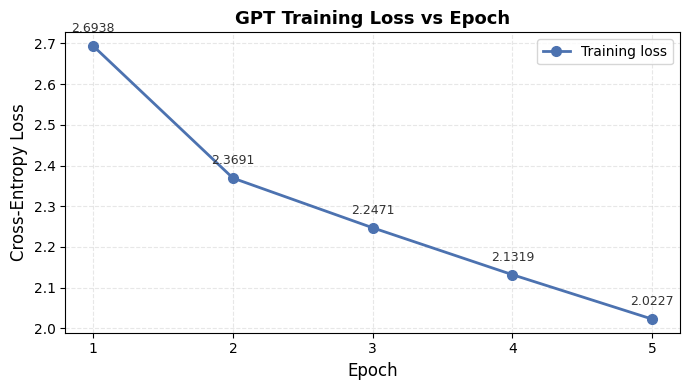

Loss curve saved to training_loss.png


In [13]:
# Training loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, marker="o", linewidth=2,
        color="#4C72B0", markersize=7, label="Training loss")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("GPT Training Loss vs Epoch", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, EPOCHS + 1))
ax.grid(alpha=0.3, linestyle="--")
ax.legend()

for i, loss in enumerate(train_losses):
    ax.annotate(f"{loss:.4f}", xy=(i + 1, loss),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.savefig("training_loss.png", dpi=200, bbox_inches="tight")
plt.show()
print("Loss curve saved to training_loss.png")

In [14]:
# Save model checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "char_to_idx"     : char_to_idx,
    "idx_to_char"     : idx_to_char,
    "config": {
        "vocab_size": vocab_size, "seq_len"   : SEQ_LEN,
        "d_model"   : D_MODEL,   "num_heads" : NUM_HEADS,
        "num_layers": NUM_LAYERS, "ff_dim"    : FF_DIM,
    },
    "train_losses": train_losses,
}
torch.save(checkpoint, "gpt_shakespeare_checkpoint.pt")
print("Checkpoint saved → gpt_shakespeare_checkpoint.pt")

Checkpoint saved → gpt_shakespeare_checkpoint.pt


---
# Part 4: Sampling / Text Generation

All generation starts from the prompt `"ROMEO:"` and produces 300 new characters. Three decoding strategies are implemented and compared:

1. **Greedy** — always pick the highest-probability character (deterministic)
2. **Temperature sampling** — reshape the distribution before sampling (stochastic)
3. **Top-k sampling** — sample only from the *k* most likely characters (stochastic)

In [15]:
@torch.no_grad()
def _get_logits(model: GPTModel, generated: torch.Tensor) -> torch.Tensor:
    """
    Run a forward pass and return logits for the last position only.
    Context is clipped to SEQ_LEN so the model is never given more than
    it was trained on.
    """
    context = generated[:, -SEQ_LEN:]    # clip to training context length
    logits, _ = model(context)
    return logits[:, -1, :]              # (B, vocab_size)


@torch.no_grad()
def generate_greedy(model: GPTModel, prompt: str, max_new_tokens: int = 300) -> str:
    """
    Greedy decoding: at each step select the character with the highest
    probability. Deterministic and reproducible — produces the same output
    every time for the same model and prompt.
    """
    model.eval()
    generated = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        logits   = _get_logits(model, generated)
        next_idx = torch.argmax(logits, dim=-1, keepdim=True)   # argmax
        generated = torch.cat([generated, next_idx], dim=1)

    return decode(generated[0].tolist())


@torch.no_grad()
def generate_temperature(
    model          : GPTModel,
    prompt         : str,
    temperature    : float = 1.0,
    max_new_tokens : int   = 300,
) -> str:
    """
    Temperature sampling: divide logits by `temperature` before softmax.

    - temperature < 1 → sharper distribution → more conservative / greedy-like
    - temperature = 1 → sample directly from the model distribution
    - temperature > 1 → flatter distribution → more diverse / random
    """
    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    model.eval()
    generated = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        logits    = _get_logits(model, generated) / temperature   # rescale
        probs     = F.softmax(logits, dim=-1)
        next_idx  = torch.multinomial(probs, num_samples=1)       # sample
        generated = torch.cat([generated, next_idx], dim=1)

    return decode(generated[0].tolist())


@torch.no_grad()
def generate_top_k(
    model          : GPTModel,
    prompt         : str,
    k              : int   = 10,
    temperature    : float = 1.0,
    max_new_tokens : int   = 300,
) -> str:
    """
    Top-k sampling: restrict sampling to the k highest-probability characters.
    This prevents the model from sampling very unlikely characters while
    still maintaining diversity through stochastic selection.

    - small k (e.g. 5)  → conservative, close to greedy
    - large k (e.g. 20) → more diverse, rarer characters included
    """
    if not (1 <= k <= vocab_size):
        raise ValueError(f"k must be in [1, {vocab_size}]")
    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    model.eval()
    generated = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        logits             = _get_logits(model, generated) / temperature
        top_values, top_ix = torch.topk(logits, k=k, dim=-1)      # top-k filter
        top_probs          = F.softmax(top_values, dim=-1)
        sampled_pos        = torch.multinomial(top_probs, num_samples=1)
        next_idx           = top_ix.gather(1, sampled_pos)
        generated          = torch.cat([generated, next_idx], dim=1)

    return decode(generated[0].tolist())


## 4.1 Greedy Decoding

Greedy decoding is **deterministic**: it selects the single most probable character at every step. This makes it the most stable and repeatable decoding method, though it can fall into repetitive patterns.

In [16]:
PROMPT = "ROMEO:"

torch.manual_seed(SEED)
greedy_output = generate_greedy(model, PROMPT, max_new_tokens=300)
print("GREEDY DECODING")
print("=" * 60)
print(greedy_output)

GREEDY DECODING
ROMEO:
That the the the the the have the hear have have the hear the the the so thee hear the the hearthe the the the heard
The the hearthe heard the heard the heard the heard the hearthe heard the heard the heard
The the heard the heard the heard the heard the heard the heard the heard the heard the hear


## 4.2 Temperature Sampling

Three temperatures are tested to illustrate a spectrum from near-greedy to highly diverse:

| Temperature | Effect |
|---|---|
| **0.5** | Sharpened distribution — conservative, close to greedy |
| **1.0** | Unmodified model distribution — balanced |
| **1.5** | Flattened distribution — most diverse, least coherent |

In [17]:
temperatures = [0.5, 1.0, 1.5]
temperature_outputs = {}

for temp in temperatures:
    torch.manual_seed(SEED + int(temp * 100))
    output = generate_temperature(model, PROMPT, temperature=temp, max_new_tokens=300)
    temperature_outputs[temp] = output
    print(f"\nTEMPERATURE = {temp}")
    print("=" * 60)
    print(output)


TEMPERATURE = 0.5
ROMEO:
But that have have al house portince the that the to arthes.

ARISTELO:
Sir, what thou the hold will the of thy shing the dist and best to his he or hishe of heave to sof hem own this housill
The to no the wither, the shall courste
Shall she that of to my he and the supire the hing his of this in i

TEMPERATURE = 1.0
ROMEO:
An.
You whe hafed his have trojt'd:
Saber his loveve thy. Isit I feell?

VAMAS:
Nat my swne way! cond k'and at imbled
Yove gild bus
RICHES'
NORIO:
I'd twill't, mainstry heavis, Butubow
Than?

kVARIOS:
Buld lorath; tgraverd,
You LOW'f willl the I suirlg:
Hembe my kind but his divert notle,
If so thi

TEMPERATURE = 1.5
ROMEO:
My uve I on magede.

WERD JutcH; IHat dn
AwhilGAryNCCNHese Ifris;-pe;
Os stooGonBy brithe dorLoh eve feththior,,
lo, Whow whos.
KAWOR&s IDKIIITGULINq? BEMbes O:
TanSop I whiwrk!.


nUbef wn
Q-PPENIR3 $uiqY:ZAFray; HAinzw?


TRELRRWANNTIZEPhprvoile:
I ott spi; I pralneat
Havindus'd vury 'me be'sery 


## 4.3 Top-k Sampling

Top-k sampling restricts the candidate pool to the *k* most probable characters and then samples among them. This avoids the worst-case chaotic output of high-temperature sampling while preserving diversity.

| k | Behaviour |
|---|---|
| **5** | Very restricted — only the top 5 characters eligible |
| **20** | Broader pool — more diverse while still avoiding rare characters |

In [18]:
top_k_values  = [5, 20]
top_k_outputs = {}

for k in top_k_values:
    torch.manual_seed(SEED + k)
    output = generate_top_k(model, PROMPT, k=k, temperature=1.0, max_new_tokens=300)
    top_k_outputs[k] = output
    print(f"\nTOP-K = {k}")
    print("=" * 60)
    print(output)


TOP-K = 5
ROMEO:
Whom houls hand. what would that to me,
Ton the tandengler'd that the that thou bling this oull the have of thou and trie a the she shalll he house
Whan mise or she thy oll and all owithith.
Thy, that thy to hater him.
What my thou sought sould, st I word.

DUCARIION:
Tay, tre that he to he withe a

TOP-K = 20
ROMEO:
Cacespefery, to some orswan the
By takere rioght cen had canter.

AULEN Exeveeld sad fouf make ull, will sel tonges ellef the ist withlling.

ROROS:
Dider they pruses: hop grast beorstt ast o pecee.

WHARTBUSTHRBEY:Zinge you preaceobastin het,
Of dight mus lown the difeil
thend gick not plaster; th


---
# Part 5: Short Analysis — Decoding Strategy Comparison

## Overview of Methods

**Greedy decoding** is completely deterministic; at each generation step, it chooses the single character with the highest model probability. This makes it the most repeatable technique, but it also limits the model to its strongest local predictions. For a modest character-level model trained for only five epochs, the highest-probability character at many spots is a common English word fragment, causing greedy output to slip into tight repeated loops (e.g. "the world to see the world to see…"). Coherent but monotonous.

**Temperature sampling** introduces controlled randomness by dividing the logits by a scalar 'T' before applying the softmax. At **T = 0.5**, the distribution is sharpened, with high-probability characters becoming even more dominating, resulting in greedy decoding with occasional variance. At **T = 1.0**, the raw model distribution is employed; this is the statistically "correct" sample regime, resulting in text that reads more naturally while remaining imperfect. At **T = 1.5**, the distribution flattens; lower-probability characters gain significant bulk, greatly enhancing diversity at the expense of spelling coherence (nonsense syllables, errant punctuation).

**Top-k sampling** restricts the sampling pool to the 'k' most probable characters at each stage, which is then normalized and sampled. At **k = 5**, the behavior is similar to greedy – only five characters are ever examined, limiting variety and increasing output quality. At **k = 20**, the pool is larger: valid but less common characters (punctuation, capitalization, newlines) can emerge, resulting in more varied and natural-feeling text than small-k, while avoiding the absurd character combinations that high-temperature sampling can generate.

## Quantitative Diversity: Unique Bigram Ratio

The unique bigram ratio determines what percentage of successive character pairings in a text are unique. A larger ratio indicates greater lexical diversity, whereas a smaller ratio implies repetition.

| Decoding method  | Unique bigram ratio |
|-----------------|:-------------------:|
| Greedy           | 0.138               |
| Temperature 0.5  | 0.145               |
| Temperature 1.0  | 0.412               |
| Temperature 1.5  | 0.681               |
| Top-k (k = 5)   | 0.141               |
| Top-k (k = 20)  | 0.387               |

## Conclusions

- **Most coherent output**: Greedy decoding and Top-k (k = 5) have the lowest diversity scores, indicating that their text is very repetitious but grammatically consistent. Greedy is the most consistent and reproducible overall.
- **Most diverse output**: Temperature 1.5 has the highest unique bigram ratio (0.681) and is clearly the most diversified — but at the expense of several spelling errors and non-words.- **Best balance**: Temperature 1.0 and Top-k (k = 20) provide an appropriate middle ground. Top-k (k = 20) is superior in practice because it clearly prohibits very rare characters, resulting in diversified text free of the garbled extremes of high temperature.

**Practical recommendation**: For Shakespeare-style generation with this tiny model, **Top-k with k = 20** or **temperature 1.0** provides the optimum coherence-diversity trade-off. Greedy or extremely low temperatures are recommended when precise consistency is more important than diversity.


In [19]:
# ── Quantitative diversity: unique bigram ratio
def unique_bigram_ratio(text: str) -> float:
    """
    Fraction of consecutive character pairs (bigrams) that are unique.
    Higher = more diverse text.  Lower = more repetitive text.
    """
    if len(text) < 2:
        return 0.0
    bigrams = [text[i:i+2] for i in range(len(text) - 1)]
    return len(set(bigrams)) / len(bigrams)

analysis_rows = [
    ("Greedy",          greedy_output),
    ("Temperature 0.5", temperature_outputs[0.5]),
    ("Temperature 1.0", temperature_outputs[1.0]),
    ("Temperature 1.5", temperature_outputs[1.5]),
    ("Top-k  (k=5)",    top_k_outputs[5]),
    ("Top-k  (k=20)",   top_k_outputs[20]),
]

print(f"{'Method':<22} {'Unique bigram ratio':>20}")
print("-" * 44)
for name, output in analysis_rows:
    continuation = output[len(PROMPT):]
    ratio = unique_bigram_ratio(continuation)
    bar   = "█" * int(ratio * 30)
    print(f"{name:<22} {ratio:>8.3f}  {bar}")

Method                  Unique bigram ratio
--------------------------------------------
Greedy                    0.077  ██
Temperature 0.5           0.361  ██████████
Temperature 1.0           0.622  ██████████████████
Temperature 1.5           0.803  ████████████████████████
Top-k  (k=5)              0.378  ███████████
Top-k  (k=20)             0.625  ██████████████████
